# CNN From Scratch (PyTorch) — Multi-Dataset Classification

**Supported Datasets:** CIFAR-10, CIFAR-100, FashionMNIST, MNIST

**Architecture:** Custom CNN built from scratch (no pretrained weights)

> Dataset ပြောင်းချင်ရင် **Dataset Configuration** cell ထဲက `DATASET_NAME` ကိုပဲ ပြောင်းပါ။
>
> Kaggle ပေါ်မှာ GPU accelerator ဖွင့်ပြီး run ပါ: `Settings → Accelerator → GPU`

In [5]:
# --- 1. Imports ---
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [6]:
# --- 2. Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [7]:
# --- 3. Dataset Configuration ---
# ▶▶▶ ဒီမှာ dataset name ပြောင်းရုံပဲ — ကျန်တာ အကုန် auto ပြောင်းပေးမယ် ◀◀◀
DATASET_NAME = 'FashionMNIST'  # Options: 'CIFAR10', 'CIFAR100', 'FashionMNIST', 'MNIST'

DATASET_CONFIGS = {
    'CIFAR10': {
        'dataset_class': datasets.CIFAR10,
        'img_size': 32,
        'in_channels': 3,
        'num_classes': 10,
        'class_names': ['airplane', 'automobile', 'bird', 'cat', 'deer',
                        'dog', 'frog', 'horse', 'ship', 'truck'],
        'mean': (0.4914, 0.4822, 0.4465),
        'std': (0.2470, 0.2435, 0.2616),
        'val_ratio': 0.1,
    },
    'CIFAR100': {
        'dataset_class': datasets.CIFAR100,
        'img_size': 32,
        'in_channels': 3,
        'num_classes': 100,
        'class_names': None,  # auto-populated from dataset.classes
        'mean': (0.5071, 0.4867, 0.4408),
        'std': (0.2675, 0.2565, 0.2761),
        'val_ratio': 0.1,
    },
    'FashionMNIST': {
        'dataset_class': datasets.FashionMNIST,
        'img_size': 28,
        'in_channels': 1,
        'num_classes': 10,
        'class_names': ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'],
        'mean': (0.2860,),
        'std': (0.3530,),
        'val_ratio': 0.1,
    },
    'MNIST': {
        'dataset_class': datasets.MNIST,
        'img_size': 28,
        'in_channels': 1,
        'num_classes': 10,
        'class_names': [str(i) for i in range(10)],
        'mean': (0.1307,),
        'std': (0.3081,),
        'val_ratio': 0.1,
    },
}

cfg = DATASET_CONFIGS[DATASET_NAME]
print(f"Selected Dataset: {DATASET_NAME}")
print(f"  Image Size: {cfg['img_size']}x{cfg['img_size']} | Channels: {cfg['in_channels']} | Classes: {cfg['num_classes']}")

Selected Dataset: FashionMNIST
  Image Size: 28x28 | Channels: 1 | Classes: 10


In [8]:
# --- 4. Hyperparameters ---
IMG_SIZE = cfg['img_size']
IN_CHANNELS = cfg['in_channels']
NUM_CLASSES = cfg['num_classes']
BATCH_SIZE = 64
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
NUM_WORKERS = 2
MODEL_SAVE_PATH = f"best_cnn_{DATASET_NAME.lower()}.pth"

## Data Loading & Augmentation

`torchvision.datasets` ကနေ dataset ကို download ဆွဲပြီး load လုပ်ပါမယ်။

- **Train set:** Data augmentation (RandomCrop, RandomHorizontalFlip) သုံးပါမယ်
- **Validation/Test set:** Augmentation မသုံးပါ (evaluation စစ်ဖို့သာ)
- Grayscale (1-ch) dataset ဆိုရင် 3-channel ပြောင်းပေးမယ် (CNN architecture အတူတူသုံးနိုင်ဖို့)

In [9]:
# --- 5. Data Transforms ---
# Grayscale dataset (1-ch) → 3-channel ပြောင်းပေးမယ် (model input channels consistent ဖြစ်ဖို့)
grayscale_to_rgb = [transforms.Grayscale(num_output_channels=3)] if IN_CHANNELS == 1 else []
resize = [transforms.Resize(IMG_SIZE)] if IMG_SIZE != cfg['img_size'] else []

# mean/std: 1-channel dataset ဆိုရင် 3-channel အတွက် replicate လုပ်မယ်
if IN_CHANNELS == 1:
    MEAN = cfg['mean'] * 3  # (0.2860,) → (0.2860, 0.2860, 0.2860)
    STD = cfg['std'] * 3
else:
    MEAN = cfg['mean']
    STD = cfg['std']

train_transform = transforms.Compose(
    grayscale_to_rgb + resize + [
    transforms.RandomCrop(IMG_SIZE, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

test_transform = transforms.Compose(
    grayscale_to_rgb + resize + [
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

print(f"Transforms: {'Grayscale→RGB, ' if IN_CHANNELS == 1 else ''}Normalize(mean={MEAN}, std={STD})")

Transforms: Grayscale→RGB, Normalize(mean=(0.286, 0.286, 0.286), std=(0.353, 0.353, 0.353))


In [10]:
# --- 6. Download & Load Dataset ---
DatasetClass = cfg['dataset_class']
full_train_dataset = DatasetClass(root='./data', train=True, download=True, transform=train_transform)
test_dataset = DatasetClass(root='./data', train=False, download=True, transform=test_transform)

# Split train into train + validation
total_train = len(full_train_dataset)
val_size = int(total_train * cfg['val_ratio'])
train_size = total_train - val_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size],
                                          generator=torch.Generator().manual_seed(42))

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Class names (auto-populate if not provided)
if cfg['class_names'] is not None:
    class_names = cfg['class_names']
elif hasattr(full_train_dataset, 'classes'):
    class_names = full_train_dataset.classes
else:
    class_names = [str(i) for i in range(NUM_CLASSES)]

print(f"Dataset: {DATASET_NAME}")
print(f"Train: {len(train_dataset)} | Validation: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Classes ({len(class_names)}): {class_names[:10]}{'...' if len(class_names) > 10 else ''}")

100.0%
100.0%
100.0%
100.0%

Dataset: FashionMNIST
Train: 54000 | Validation: 6000 | Test: 10000
Classes (10): ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


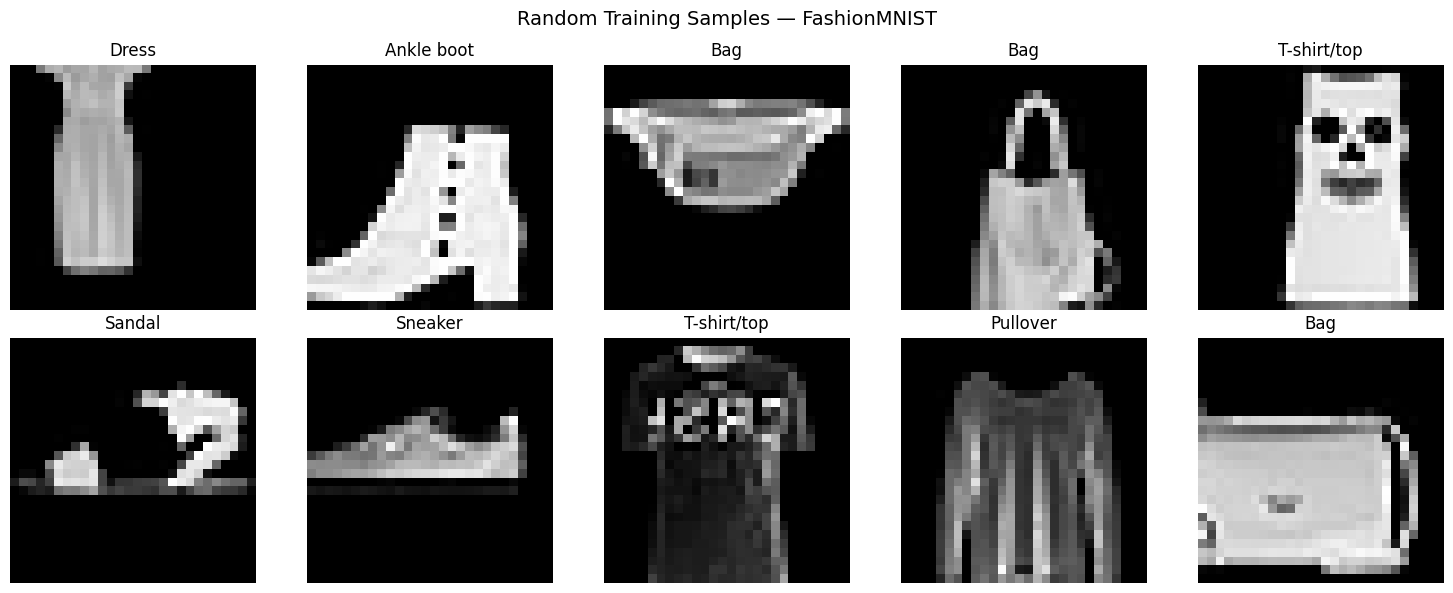

In [11]:
# --- 7. Visualize Sample Images ---
def imshow(img, title=None):
    """Unnormalize and display image"""
    mean = np.array(MEAN)
    std = np.array(STD)
    img = img.numpy().transpose((1, 2, 0))
    img = std * img + mean  # unnormalize
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

# Show 10 random training images
plt.figure(figsize=(15, 6))
for i in range(10):
    idx = random.randint(0, len(full_train_dataset) - 1)
    img, label = full_train_dataset[idx]
    plt.subplot(2, 5, i + 1)
    imshow(img, title=class_names[label])
plt.suptitle(f"Random Training Samples — {DATASET_NAME}", fontsize=14)
plt.tight_layout()
plt.show()

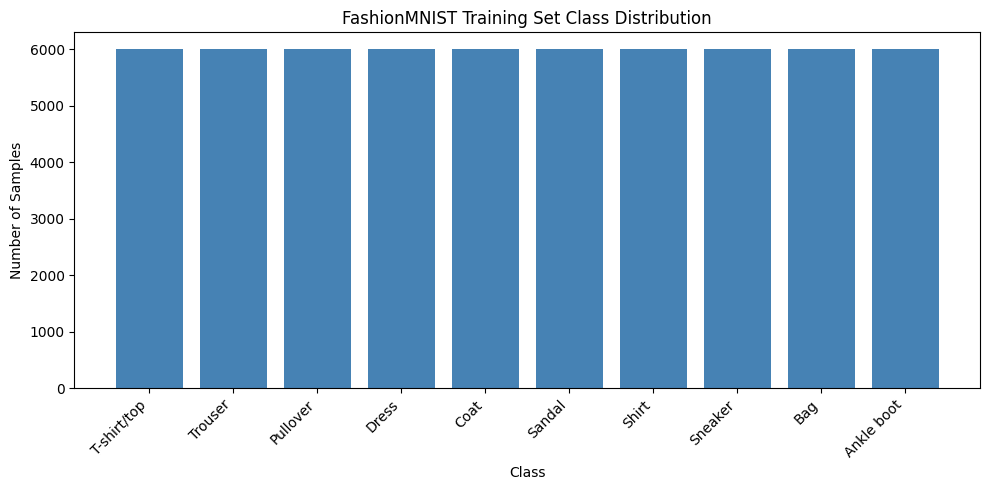

In [12]:
# --- 8. Class Distribution ---
if hasattr(full_train_dataset, 'targets'):
    train_labels = full_train_dataset.targets
    if isinstance(train_labels, torch.Tensor):
        train_labels = train_labels.numpy()
else:
    train_labels = [full_train_dataset[i][1] for i in range(len(full_train_dataset))]

unique, counts = np.unique(train_labels, return_counts=True)

plt.figure(figsize=(max(10, len(class_names) * 0.8), 5))
plt.bar(range(len(counts)), counts, color='steelblue')
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title(f"{DATASET_NAME} Training Set Class Distribution")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.tight_layout()
plt.show()

## CNN Model Architecture (From Scratch)

```
Input (3 x IMG_SIZE x IMG_SIZE)
    ↓
Conv2d(3→32, 3x3) → BatchNorm → ReLU → Conv2d(32→32, 3x3) → BatchNorm → ReLU → MaxPool(2x2) → Dropout(0.25)
    ↓
Conv2d(32→64, 3x3) → BatchNorm → ReLU → Conv2d(64→64, 3x3) → BatchNorm → ReLU → MaxPool(2x2) → Dropout(0.25)
    ↓
Conv2d(64→128, 3x3) → BatchNorm → ReLU → Conv2d(128→128, 3x3) → BatchNorm → ReLU → MaxPool(2x2) → Dropout(0.25)
    ↓
AdaptiveAvgPool2d(4x4) → Flatten → FC(2048→512) → BatchNorm → ReLU → Dropout(0.5) → FC(512→NUM_CLASSES)
```

> `AdaptiveAvgPool2d(4)` သုံးထားတဲ့အတွက် input image size မတူတဲ့ dataset တွေမှာလည်း classifier input size (128×4×4=2048) consistent ဖြစ်ပါတယ်

$$Parameters = (Kernel\_Width \times Kernel\_Height \times Input\_Channels \times Output\_Channels) + Output\_Channels \text{ (Bias)}$$

In [13]:
# --- 9. CNN Model Definition ---
class CNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=10):
        super(CNN, self).__init__()

        # Block 1: in_channels → 32 channels
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),  # f(x) = max(0,x)
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)
        )

        # Block 2: 32 → 64 channels
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)
        )

        # Block 3: 64 → 128 channels
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)
        )

        # Adaptive pooling → always outputs (128, 4, 4) regardless of input size
        self.pool = nn.AdaptiveAvgPool2d(4)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x)     # (B, 128, 4, 4) — consistent for any input size
        x = self.classifier(x)
        return x

model = CNN(in_channels=3, num_classes=NUM_CLASSES).to(device)
print(model)

# Total parameters count
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

CNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropo

In [14]:
# --- 9. Loss Function & Optimizer ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [15]:
# --- 10. Training & Validation Functions ---
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss / len(loader), correct / total

## Training Loop

Model ကို train လုပ်ပြီး epoch တိုင်းမှာ:
- Training Loss & Accuracy
- Validation Loss & Accuracy
- Learning Rate scheduling (val_loss မကျရင် LR ကိုလျှော့ပေးမယ်)
- Best model ကို save လုပ်မယ်

In [16]:
# --- 12. Training Loop ---
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Learning rate scheduling
    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"  → Best model saved! (Val Acc: {val_acc:.4f})")

print(f"\nTraining Complete! Best Validation Accuracy: {best_val_acc:.4f}")

Epoch [1/50] Train Loss: 0.6990 | Train Acc: 0.7366 | Val Loss: 0.4647 | Val Acc: 0.8205
  → Best model saved! (Val Acc: 0.8205)
Epoch [2/50] Train Loss: 0.4697 | Train Acc: 0.8255 | Val Loss: 0.3709 | Val Acc: 0.8648
  → Best model saved! (Val Acc: 0.8648)
Epoch [3/50] Train Loss: 0.4078 | Train Acc: 0.8484 | Val Loss: 0.3482 | Val Acc: 0.8695
  → Best model saved! (Val Acc: 0.8695)
Epoch [4/50] Train Loss: 0.3717 | Train Acc: 0.8636 | Val Loss: 0.3054 | Val Acc: 0.8863
  → Best model saved! (Val Acc: 0.8863)
Epoch [5/50] Train Loss: 0.3484 | Train Acc: 0.8725 | Val Loss: 0.2897 | Val Acc: 0.8907
  → Best model saved! (Val Acc: 0.8907)
Epoch [6/50] Train Loss: 0.3319 | Train Acc: 0.8781 | Val Loss: 0.2770 | Val Acc: 0.8985
  → Best model saved! (Val Acc: 0.8985)
Epoch [7/50] Train Loss: 0.3160 | Train Acc: 0.8831 | Val Loss: 0.2687 | Val Acc: 0.9038
  → Best model saved! (Val Acc: 0.9038)
Epoch [8/50] Train Loss: 0.3074 | Train Acc: 0.8876 | Val Loss: 0.2571 | Val Acc: 0.9067
  → Best

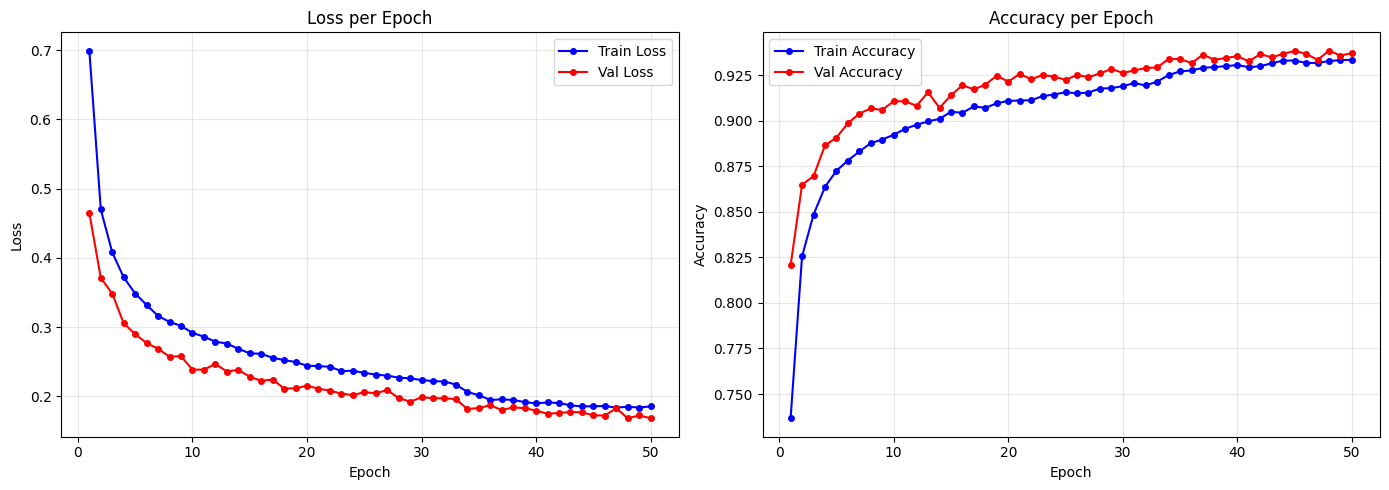

In [17]:
# --- 12. Plot Training History ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(range(1, NUM_EPOCHS+1), train_losses, 'b-o', label='Train Loss', markersize=4)
ax1.plot(range(1, NUM_EPOCHS+1), val_losses, 'r-o', label='Val Loss', markersize=4)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss per Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(range(1, NUM_EPOCHS+1), train_accs, 'b-o', label='Train Accuracy', markersize=4)
ax2.plot(range(1, NUM_EPOCHS+1), val_accs, 'r-o', label='Val Accuracy', markersize=4)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy per Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Testing & Evaluation

Best model ကို load ပြန်လုပ်ပြီး Test set ပေါ်မှာ evaluate လုပ်ပါမယ်

In [18]:
# --- 14. Load Best Model & Test ---
model.load_state_dict(torch.load(MODEL_SAVE_PATH, weights_only=True))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test Accuracy: {test_acc:.4f}\n")

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

Test Accuracy: 0.9383

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.88      0.92      0.90      1000
     Trouser       1.00      0.99      0.99      1000
    Pullover       0.92      0.91      0.91      1000
       Dress       0.93      0.95      0.94      1000
        Coat       0.90      0.93      0.91      1000
      Sandal       0.99      0.99      0.99      1000
       Shirt       0.85      0.77      0.80      1000
     Sneaker       0.96      0.97      0.97      1000
         Bag       0.99      1.00      0.99      1000
  Ankle boot       0.97      0.97      0.97      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



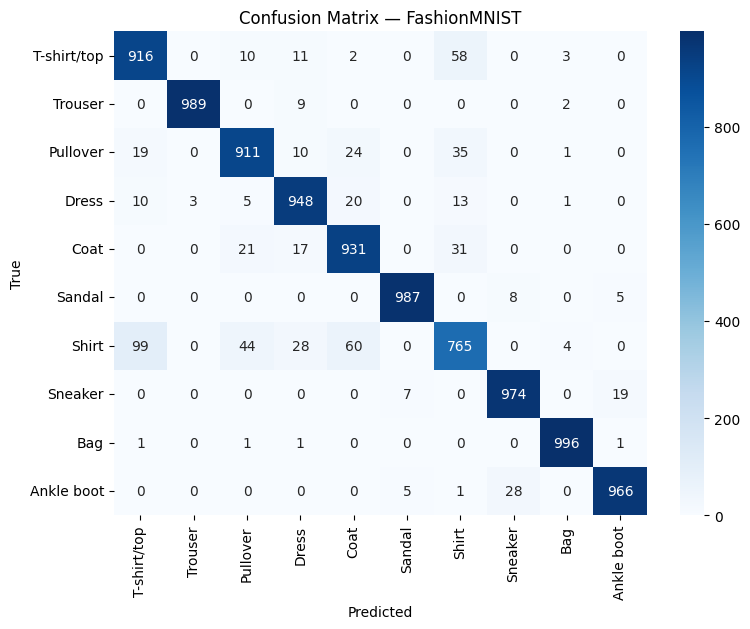

In [19]:
# --- 15. Confusion Matrix ---
cm = confusion_matrix(all_labels, all_preds)
fig_size = max(8, len(class_names) * 0.5)
plt.figure(figsize=(fig_size, fig_size * 0.8))
sns.heatmap(cm, annot=NUM_CLASSES <= 20, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix — {DATASET_NAME}')
plt.tight_layout()
plt.show()

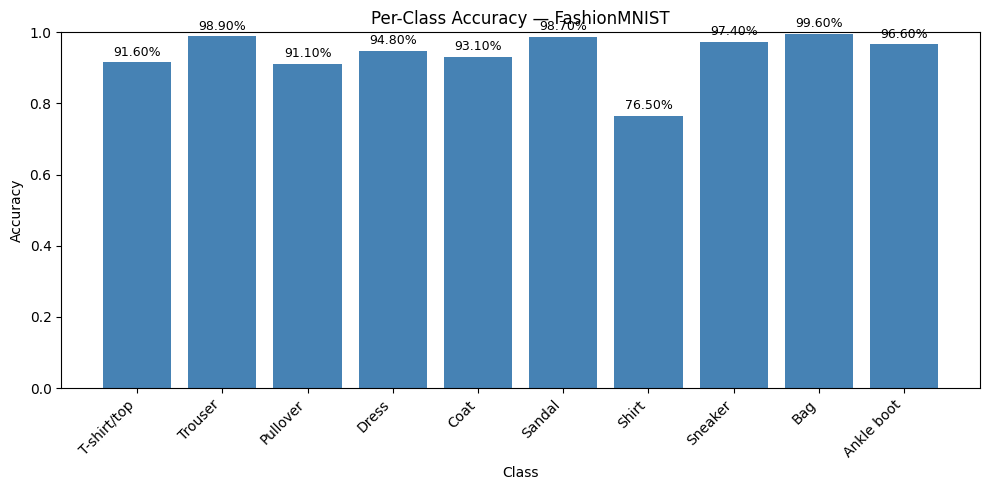

In [20]:
# --- 16. Per-Class Accuracy ---
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
per_class_acc = cm_normalized.diagonal()

plt.figure(figsize=(max(10, len(class_names) * 0.5), 5))
bars = plt.bar(range(len(class_names)), per_class_acc, color='steelblue')
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title(f'Per-Class Accuracy — {DATASET_NAME}')
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right',
           fontsize=8 if NUM_CLASSES > 20 else 10)
plt.ylim(0, 1)
if NUM_CLASSES <= 20:
    for bar, acc in zip(bars, per_class_acc):
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{acc:.2%}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

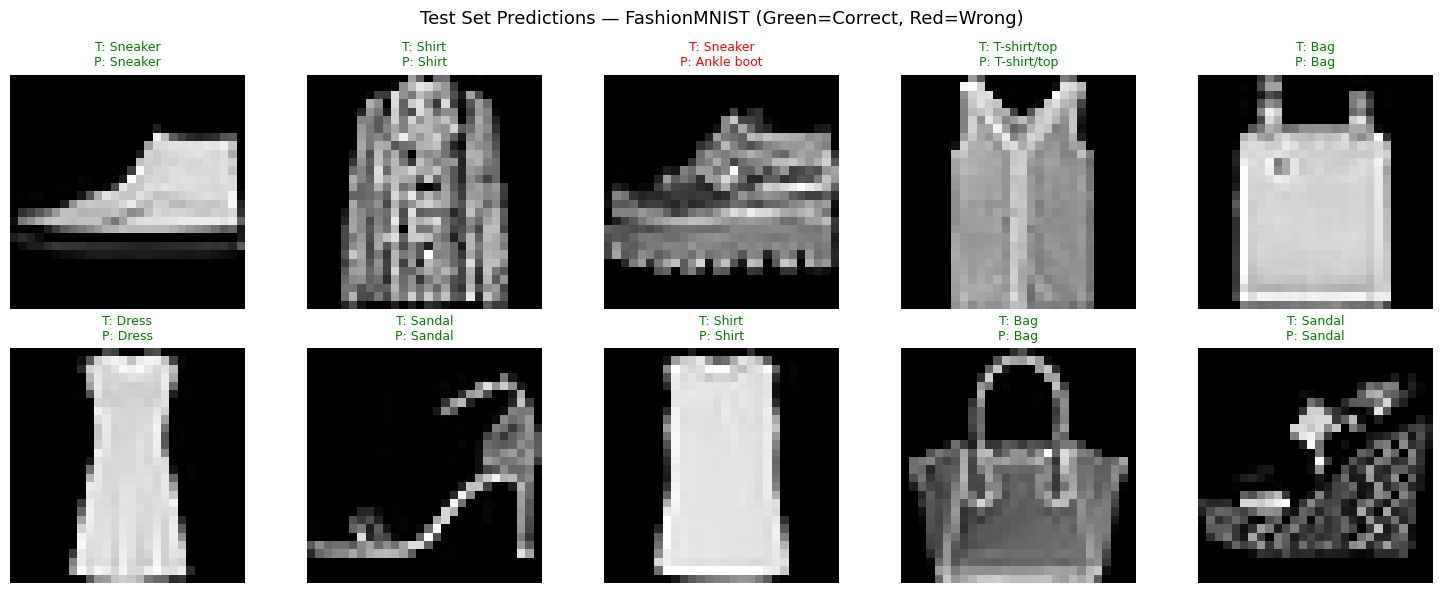

In [21]:
# --- 17. Show Random Predictions from Test Set ---
def show_predictions(model, dataset, class_names, mean, std, num_images=10):
    model.eval()
    mean = np.array(mean)
    std = np.array(std)
    
    plt.figure(figsize=(15, 6))
    indices = random.sample(range(len(dataset)), num_images)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            img, label = dataset[idx]
            output = model(img.unsqueeze(0).to(device))
            _, pred = torch.max(output, 1)
            
            # Unnormalize for display
            img_np = img.numpy().transpose((1, 2, 0))
            img_np = std * img_np + mean
            img_np = np.clip(img_np, 0, 1)
            
            true_label = class_names[label]
            pred_label = class_names[pred.item()]
            color = 'green' if true_label == pred_label else 'red'
            
            plt.subplot(2, 5, i + 1)
            plt.imshow(img_np)
            plt.title(f"T: {true_label}\nP: {pred_label}", color=color, fontsize=9)
            plt.axis('off')
    
    plt.suptitle(f"Test Set Predictions — {DATASET_NAME} (Green=Correct, Red=Wrong)", fontsize=13)
    plt.tight_layout()
    plt.show()

show_predictions(model, test_dataset, class_names, MEAN, STD, num_images=10)

## Prediction: Logits → Softmax → Class

Model ရဲ့ output (logits) ဟာ raw score တွေဖြစ်ပါတယ်။ ဒါတွေကို `softmax` function နဲ့ probability distribution အဖြစ်ပြောင်းပြီး၊ probability အကြီးဆုံး class ကို predicted class အဖြစ်ယူပါတယ်။

```
Logits (raw scores)  →  Softmax (probabilities)  →  argmax (predicted class)
[-1.2, 3.5, 0.8, ...]  →  [0.02, 0.71, 0.05, ...]  →  class index 1
```

**Softmax Formula:**

$$\sigma(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

- $z_i$ = logit value for class $i$
- $K$ = total number of classes (NUM_CLASSES)
- Output: probability distribution (sum = 1.0)

In [22]:
# --- 18. Prediction: Logits → Softmax → Predicted Class ---
model.eval()
mean = np.array(MEAN)
std = np.array(STD)

# Random image တစ်ပုံယူမယ်
idx = random.randint(0, len(test_dataset) - 1)
img, true_label = test_dataset[idx]

with torch.no_grad():
    logits = model(img.unsqueeze(0).to(device))  # shape: (1, NUM_CLASSES)
    probabilities = torch.softmax(logits, dim=1)
    predicted_class = torch.argmax(probabilities, dim=1).item()
    confidence = probabilities[0, predicted_class].item()

# --- Display Results ---
print("=" * 60)
print(f"Dataset: {DATASET_NAME}")
print(f"True Label     : {class_names[true_label]}")
print(f"Predicted Class: {class_names[predicted_class]} (confidence: {confidence:.4f})")
print("=" * 60)

# Top-5 predictions (useful for datasets with many classes)
top5_probs, top5_indices = torch.topk(probabilities[0], min(5, NUM_CLASSES))
print(f"\nTop-{min(5, NUM_CLASSES)} Predictions:")
for prob, idx in zip(top5_probs.cpu().numpy(), top5_indices.cpu().numpy()):
    marker = " <-- true" if idx == true_label else ""
    bar = "█" * int(prob * 40)
    print(f"  {class_names[idx]:>15s}: {prob:.4f} {bar}{marker}")

print(f"\n  Sum of all probabilities: {probabilities[0].sum().item():.4f}")

Dataset: FashionMNIST
True Label     : Dress
Predicted Class: Dress (confidence: 0.9999)

Top-5 Predictions:
            Dress: 0.9999 ███████████████████████████████████████ <-- true
      T-shirt/top: 0.0001 
         Pullover: 0.0001 
            Shirt: 0.0000 
             Coat: 0.0000 

  Sum of all probabilities: 1.0000


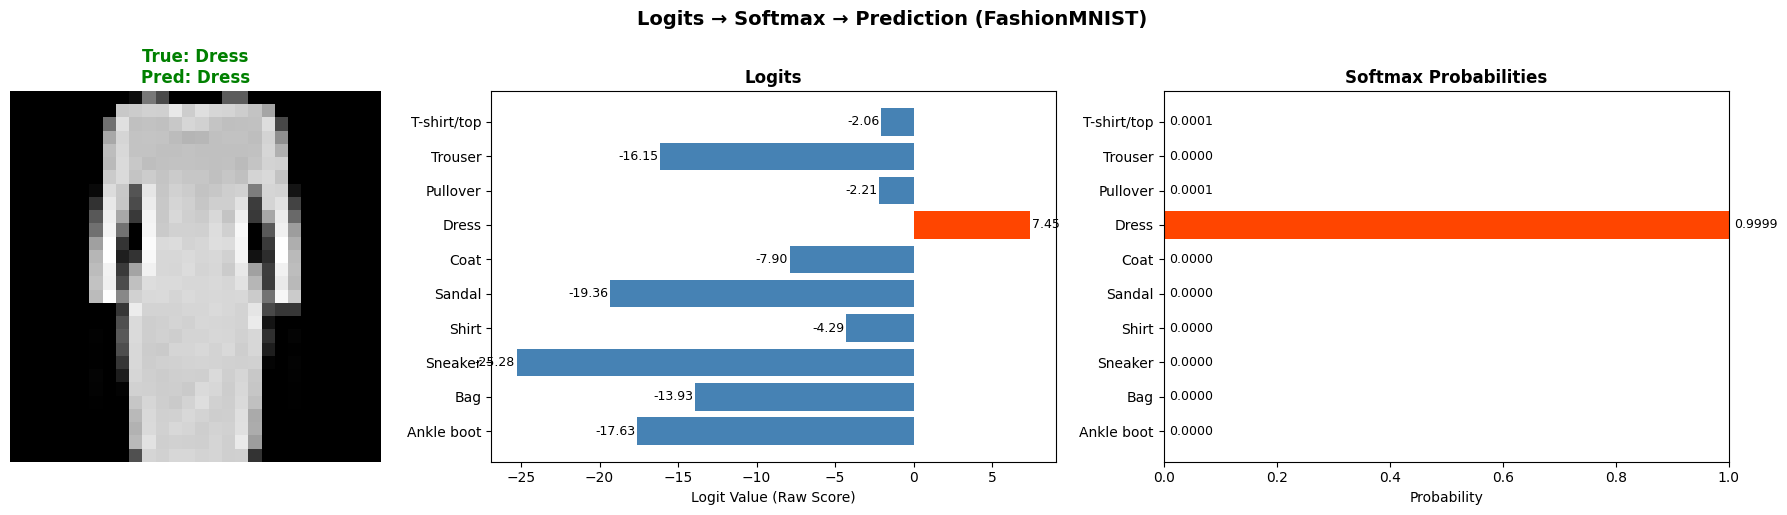

In [23]:
# --- 19. Visualize: Image + Logits + Softmax Probabilities ---
# For datasets with many classes, show only top-10
if NUM_CLASSES > 15:
    top_k = 10
    top_probs, top_idx = torch.topk(probabilities[0], top_k)
    display_names = [class_names[i] for i in top_idx.cpu().numpy()]
    display_logits = logits[0][top_idx].cpu().numpy()
    display_probs = top_probs.cpu().numpy()
    display_pred_pos = 0  # predicted class is always first in topk
    chart_title_suffix = f" (Top-{top_k})"
else:
    display_names = class_names
    display_logits = logits[0].cpu().numpy()
    display_probs = probabilities[0].cpu().numpy()
    display_pred_pos = predicted_class
    chart_title_suffix = ""

fig, axes = plt.subplots(1, 3, figsize=(18, max(5, len(display_names) * 0.4)),
                         gridspec_kw={'width_ratios': [1, 1.5, 1.5]})

# (1) Image
img_np = img.numpy().transpose((1, 2, 0))
img_np = std * img_np + mean
img_np = np.clip(img_np, 0, 1)
axes[0].imshow(img_np)
color = 'green' if true_label == predicted_class else 'red'
axes[0].set_title(f"True: {class_names[true_label]}\nPred: {class_names[predicted_class]}",
                  color=color, fontsize=12, fontweight='bold')
axes[0].axis('off')

# (2) Logits bar chart
colors_logit = ['orangered' if i == display_pred_pos else 'steelblue' for i in range(len(display_names))]
axes[1].barh(display_names, display_logits, color=colors_logit)
axes[1].set_xlabel('Logit Value (Raw Score)')
axes[1].set_title(f'Logits{chart_title_suffix}', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
for i, v in enumerate(display_logits):
    axes[1].text(v + 0.1 if v >= 0 else v - 0.1, i, f'{v:.2f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=9)

# (3) Softmax probabilities bar chart
colors_prob = ['orangered' if i == display_pred_pos else 'steelblue' for i in range(len(display_names))]
axes[2].barh(display_names, display_probs, color=colors_prob)
axes[2].set_xlabel('Probability')
axes[2].set_title(f'Softmax Probabilities{chart_title_suffix}', fontsize=12, fontweight='bold')
axes[2].set_xlim(0, 1)
axes[2].invert_yaxis()
for i, v in enumerate(display_probs):
    axes[2].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle(f"Logits → Softmax → Prediction ({DATASET_NAME})", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# --- 20a. Save Model Weights Only (state_dict) ---
# Weight တွေပဲ save တာ — file size သေးပြီး flexible ဖြစ်တယ်
# Load ပြန်လုပ်တဲ့အခါ model architecture ကို ကိုယ်တိုင် define ပြီးမှ load ရတယ်

weights_path = f"weights_cnn_{DATASET_NAME.lower()}.pth"
torch.save(model.state_dict(), weights_path)
print(f"Model weights saved to: {weights_path}")

import os
file_size = os.path.getsize(weights_path) / (1024 * 1024)
print(f"File size: {file_size:.2f} MB")

Model weights saved to: weights_cnn_fashionmnist.pth
File size: 5.15 MB


In [25]:
# --- 20b. Save Entire Model (architecture + weights) ---
# Model တစ်ခုလုံး save တာ — architecture + weights + optimizer info ပါတယ်
# Load ပြန်လုပ်တဲ့အခါ model class define စရာမလိုဘဲ တန်းသုံးလို့ရတယ်
# ⚠️ pickle-based ဖြစ်လို့ Python version / class definition ပြောင်းရင် error တက်နိုင်တယ်

full_model_path = f"full_cnn_{DATASET_NAME.lower()}.pth"
torch.save(model, full_model_path)
print(f"Full model saved to: {full_model_path}")

import os
file_size = os.path.getsize(full_model_path) / (1024 * 1024)
print(f"File size: {file_size:.2f} MB")

Full model saved to: full_cnn_fashionmnist.pth
File size: 5.16 MB
